In [8]:
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
zip_file_path = 'C:/Users/Allis/Downloads/healthcare_dataset.csv (1).zip'
extraction_path = 'C:/Users/Allis/Downloads/healthcare_dataset.csv'
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

csv_file_path = os.path.join(extraction_path, 'healthcare_dataset.csv')
df = pd.read_csv(csv_file_path)
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [11]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [12]:
df['Age'].value_counts()

Age
38    897
37    893
57    887
80    864
34    864
     ... 
88     25
16     24
14     18
13     14
89      8
Name: count, Length: 77, dtype: int64

In [13]:
df['Gender'].value_counts()

Gender
Male      27774
Female    27726
Name: count, dtype: int64

In [14]:
df['Blood Type'].value_counts()

Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

In [15]:
df['Medical Condition'].value_counts()

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

In [16]:
df['Test Results'].value_counts()

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

In [17]:
df['Doctor'].value_counts()

Doctor
Michael Smith           27
Robert Smith            22
John Smith              22
Michael Johnson         20
James Smith             20
                        ..
Audrey Zimmerman DDS     1
Justin Banks             1
Joseph Williams Jr.      1
Jason Franklin           1
Jeffrey Moore            1
Name: count, Length: 40341, dtype: int64

In [18]:
df['Insurance Provider'].value_counts()

Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

In [19]:
df['Admission Type'].value_counts()

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Text(0.5, 1.0, 'Age Distribution')

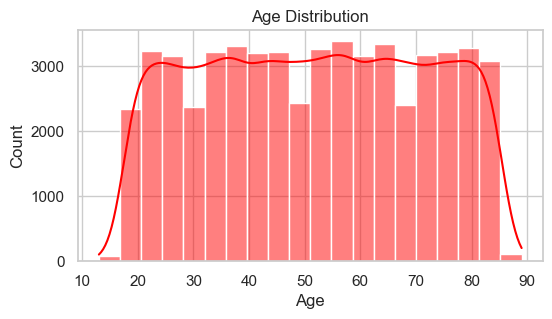

In [22]:
sns.set(style='whitegrid')
plt.figure(figsize=(6, 3))
sns.histplot(df['Age'], bins=20, kde=True, color='red')
plt.title('Age Distribution')

Text(0.5, 0, 'Billing Amount')

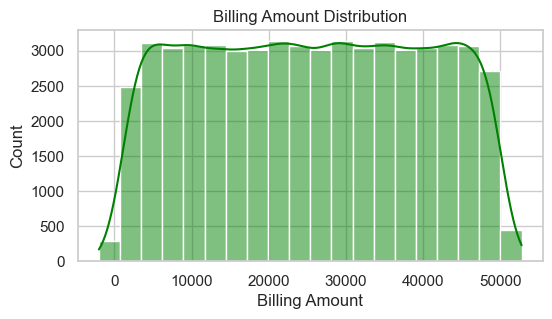

In [23]:
plt.figure(figsize=(6, 3))
sns.histplot(df['Billing Amount'], bins=20, kde=True, color='green')
plt.title('Billing Amount Distribution')
plt.xlabel('Billing Amount')

In [24]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

Text(0.5, 0, 'Days')

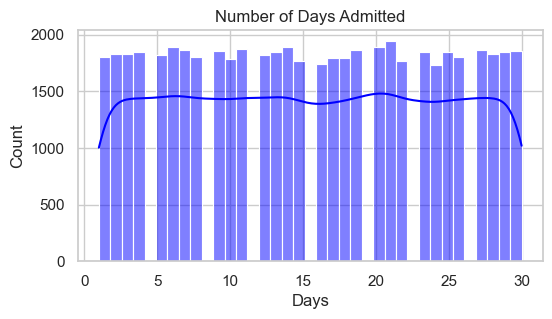

In [25]:
plt.figure(figsize=(6, 3))
sns.histplot(df['Length_of_Stay'], kde=True, color='blue')
plt.title('Number of Days Admitted')
plt.xlabel('Days')

In [26]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [27]:
# fix column names (remove leading/trailing spaces if any)
df.rename(columns=lambda x: x.strip(), inplace=True)

# define the high-cost admission threshold (using median billing amount)
cost_threshold = df['Billing Amount'].median()
df['High_Cost'] = (df['Billing Amount'] > cost_threshold).astype(int)

# check if 'High_Cost' exists before proceeding
if 'High_Cost' not in df.columns:
    raise ValueError("Error: 'High_Cost' column was not created correctly!")

In [28]:
# select features for analysis
categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Insurance Provider']
numerical_cols = ['Age', 'Length_of_Stay']
target = 'High_Cost'

# separate features and target variable
X = df[categorical_cols + numerical_cols]
y = df[target]

In [29]:
# One-Hot Encoding + Standardization Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Scale numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # Encode categorical features
    ]
)

# split dataset into training/testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
print("\n Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# K-Nearest Neighbors (KNN)
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)
print("\n K-Nearest Neighbors Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Logistic Regression
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)
print("\n Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))


 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.58      0.57      5473
           1       0.57      0.55      0.56      5521

    accuracy                           0.56     10994
   macro avg       0.56      0.56      0.56     10994
weighted avg       0.56      0.56      0.56     10994


 K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.54      0.53      5473
           1       0.54      0.54      0.54      5521

    accuracy                           0.54     10994
   macro avg       0.54      0.54      0.54     10994
weighted avg       0.54      0.54      0.54     10994


 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.53      0.51      5473
           1       0.50      0.48      0.49      5521

    accuracy                           0.50     10994

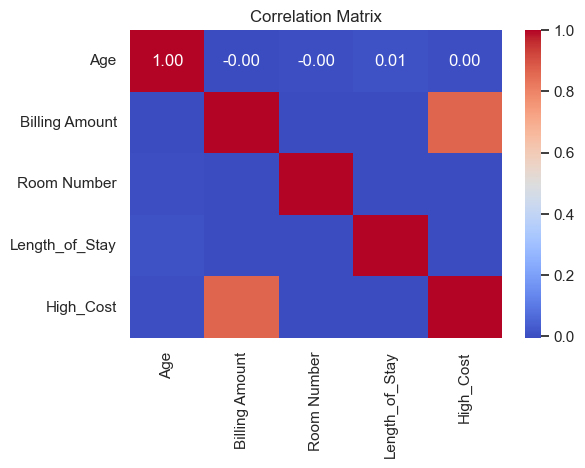

In [30]:
# Feature Correlation Heatmap (for numerical variables)
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Final Model Interpretation

The Random Forest classifier achieved moderate performance, with accuracy, precision, recall, and F1-scores consistently around 0.56. While this indicates the model captures some meaningful signal, overall discrimination remains limited, suggesting the outcome is influenced by factors not fully represented in the current feature set.

Feature importance analysis highlights which variables contribute most to prediction, offering direction for future feature engineering and data collection. ROC-AUC results further confirm that class separation is challenging, reinforcing the need for domain-driven enhancements rather than purely algorithmic tuning.

From a practical perspective, this model is best suited as a decision-support tool rather than a fully automated solution. Through threshold tuning, the model can be adapted to prioritize either recall or precision depending on operational goals—demonstrating how machine learning performance must be evaluated not only by metrics, but by business impact and risk tolerance.